***Libraries Importing***

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("All libraries are Loaded!")

All libraries are Loaded!


***Dataset Loading****

In [2]:

df = pd.read_csv(r"C:\Users\ankit\Downloads\Python Project\Healthcare\healthcare_dataset.csv")

print("Dataset is Loaded")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

Dataset is Loaded
Rows: 55500, Columns: 15


***Dataset First View***

In [3]:

print(df.head())


Dataset First View
            Name  Age  Gender Blood Type Medical Condition Date of Admission  \
0  Bobby JacksOn   30    Male         B-            Cancer        2024-01-31   
1   LesLie TErRy   62    Male         A+           Obesity        2019-08-20   
2    DaNnY sMitH   76  Female         A-           Obesity        2022-09-22   
3   andrEw waTtS   28  Female         O+          Diabetes        2020-11-18   
4  adrIENNE bEll   43  Female        AB+            Cancer        2022-09-19   

             Doctor                    Hospital Insurance Provider  \
0     Matthew Smith             Sons and Miller         Blue Cross   
1   Samantha Davies                     Kim Inc           Medicare   
2  Tiffany Mitchell                    Cook PLC              Aetna   
3       Kevin Wells  Hernandez Rogers and Vang,           Medicare   
4    Kathleen Hanna                 White-White              Aetna   

   Billing Amount  Room Number Admission Type Discharge Date   Medication  \
0 

***COLUMNS AND DATATYPES*** 

In [6]:

print(df.dtypes)


Name                   object
Age                     int64
Gender                 object
Blood Type             object
Medical Condition      object
Date of Admission      object
Doctor                 object
Hospital               object
Insurance Provider     object
Billing Amount        float64
Room Number             int64
Admission Type         object
Discharge Date         object
Medication             object
Test Results           object
dtype: object


***NULL VALUES (Blank cells)***

In [9]:

print(df.isnull().sum())


Name                  0
Age                   0
Gender                0
Blood Type            0
Medical Condition     0
Date of Admission     0
Doctor                0
Hospital              0
Insurance Provider    0
Billing Amount        0
Room Number           0
Admission Type        0
Discharge Date        0
Medication            0
Test Results          0
dtype: int64


***BASIC STATISTICS***

In [10]:

print(df.describe())

                Age  Billing Amount   Room Number
count  55500.000000    55500.000000  55500.000000
mean      51.539459    25539.316097    301.134829
std       19.602454    14211.454431    115.243069
min       13.000000    -2008.492140    101.000000
25%       35.000000    13241.224652    202.000000
50%       52.000000    25538.069376    302.000000
75%       68.000000    37820.508436    401.000000
max       89.000000    52764.276736    500.000000


In [11]:
# Step 1: Name column fix 
df['Name'] = df['Name'].str.title()



# Step 2: Date columns in Proper Format
df['Date of Admission'] = pd.to_datetime(df['Date of Admission'])
df['Discharge Date'] = pd.to_datetime(df['Discharge Date'])



# Step 3: New Columns created — How many days patient were admited
df['Length of Stay'] = (df['Discharge Date'] - df['Date of Admission']).dt.days



# Step 4: Duplicates checking
print(f"Duplicates First: {df.duplicated().sum()}")
df = df.drop_duplicates()
print(f"Duplicates at last: {df.duplicated().sum()}")



# Step 5: Checking Billing Amount negative values 
print(f"\nNegative billing: {(df['Billing Amount'] < 0).sum()}")



# Step 6: Final clean data Size
print(f"\n✅ Clean dataset ready!")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")
print(f"\nNew columns: {df.columns.tolist()}")

Duplicates First: 534
Duplicates at last: 0

Negative billing: 106

✅ Clean dataset ready!
Rows: 54966, Columns: 16

New columns: ['Name', 'Age', 'Gender', 'Blood Type', 'Medical Condition', 'Date of Admission', 'Doctor', 'Hospital', 'Insurance Provider', 'Billing Amount', 'Room Number', 'Admission Type', 'Discharge Date', 'Medication', 'Test Results', 'Length of Stay']


In [12]:
# NEW COLUMN 2: Age Group ────────────────────────


df['Age Group'] = pd.cut(
    df['Age'],
    
    bins   = [0, 18, 35, 50, 65, 100],
    labels = ['0-18', '19-35', '36-50', '51-65', '65+']
)

print("✅ Age Group column created!")
print(df['Age Group'].value_counts())



✅ Age Group column created!
Age Group
65+      16096
19-35    13519
51-65    12298
36-50    12167
0-18       886
Name: count, dtype: int64


In [13]:
# NEW COLUMN 3: Year aur Month ──────────────────


# Power BI mein trend dekhne ke liye
df['Admission Year']  = df['Date of Admission'].dt.year
df['Admission Month'] = df['Date of Admission'].dt.month_name()

print("✅ Year and Month columns created!")
print("Years:", sorted(df['Admission Year'].unique()))


✅ Year and Month columns created!
Years: [np.int32(2019), np.int32(2020), np.int32(2021), np.int32(2022), np.int32(2023), np.int32(2024)]


In [14]:

# Final cleaned data dekho ──────────────────────

print("=== FINAL DATASET ===")
print("Shape:", df.shape)
print("\nAll Columns:", df.columns.tolist())
print("\nMissing Values:", df.isnull().sum().sum())
print("\nSample:")
df.head()

=== FINAL DATASET ===
Shape: (54966, 19)

All Columns: ['Name', 'Age', 'Gender', 'Blood Type', 'Medical Condition', 'Date of Admission', 'Doctor', 'Hospital', 'Insurance Provider', 'Billing Amount', 'Room Number', 'Admission Type', 'Discharge Date', 'Medication', 'Test Results', 'Length of Stay', 'Age Group', 'Admission Year', 'Admission Month']

Missing Values: 0

Sample:


,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results,Length of Stay,Age Group,Admission Year,Admission Month
0,Bobby Jackson,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal,2,19-35,2024,January
1,Leslie Terry,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive,6,51-65,2019,August
2,Danny Smith,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal,15,65+,2022,September
3,Andrew Watts,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal,30,19-35,2020,November
4,Adrienne Bell,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal,20,36-50,2022,September


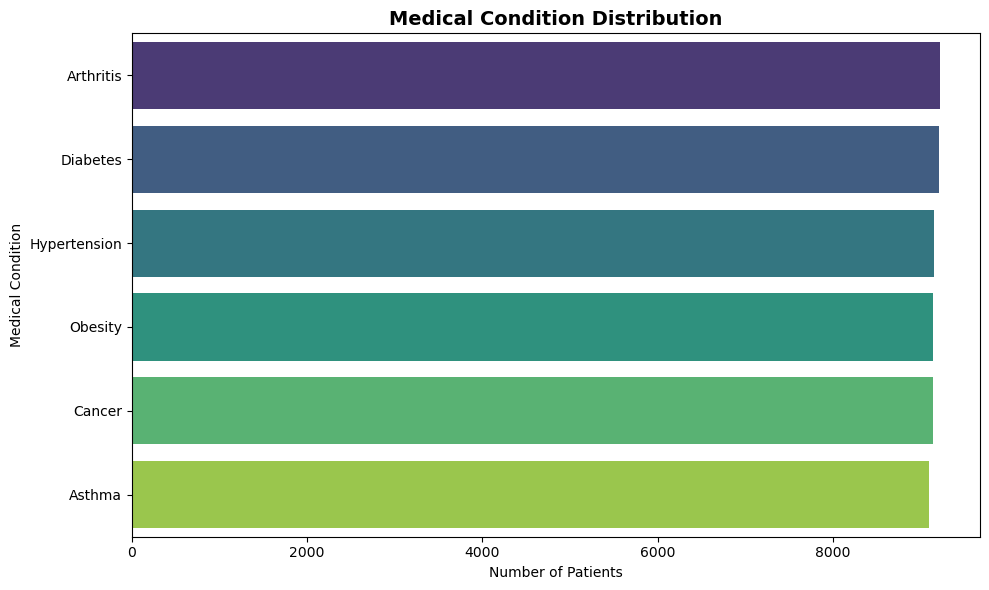

In [15]:
# VISUAL 1: Medical Condition Distribution ───────

plt.figure(figsize=(10, 6))
condition_counts = df['Medical Condition'].value_counts()
sns.barplot(x=condition_counts.values, y=condition_counts.index, palette="viridis")
plt.title('Medical Condition Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Number of Patients')
plt.ylabel('Medical Condition')
plt.tight_layout()
plt.savefig('chart1_medical_condition.png', dpi=150)
plt.show()

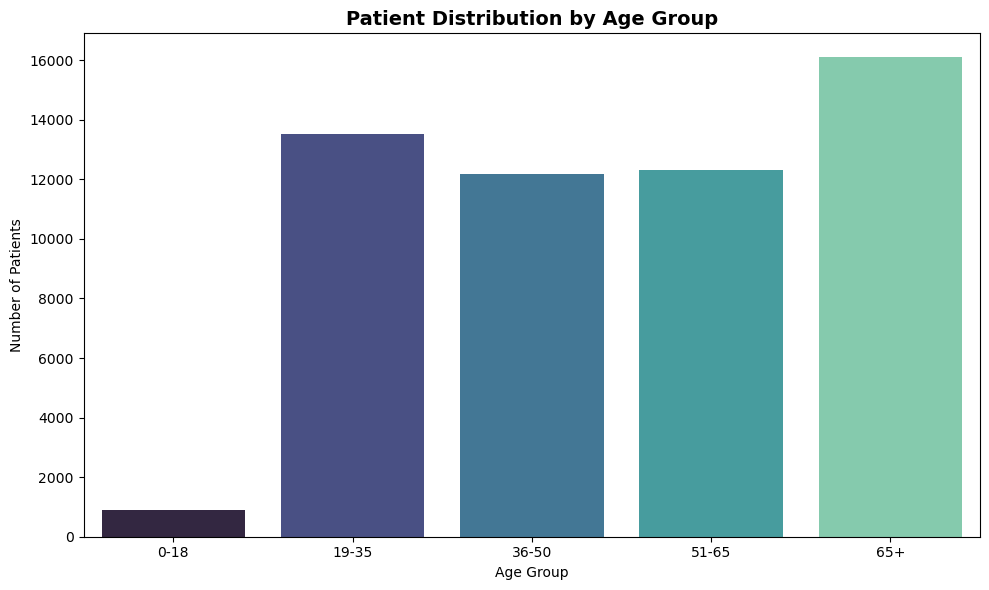

In [16]:
# VISUAL 3: Age Group wise Patient Count ──────────

plt.figure(figsize=(10, 6))
age_counts = df['Age Group'].value_counts().sort_index()
sns.barplot(x=age_counts.index, y=age_counts.values, palette="mako")
plt.title('Patient Distribution by Age Group', fontsize=14, fontweight='bold')
plt.xlabel('Age Group')
plt.ylabel('Number of Patients')
plt.tight_layout()
plt.savefig('chart3_age_group.png', dpi=150)
plt.show()

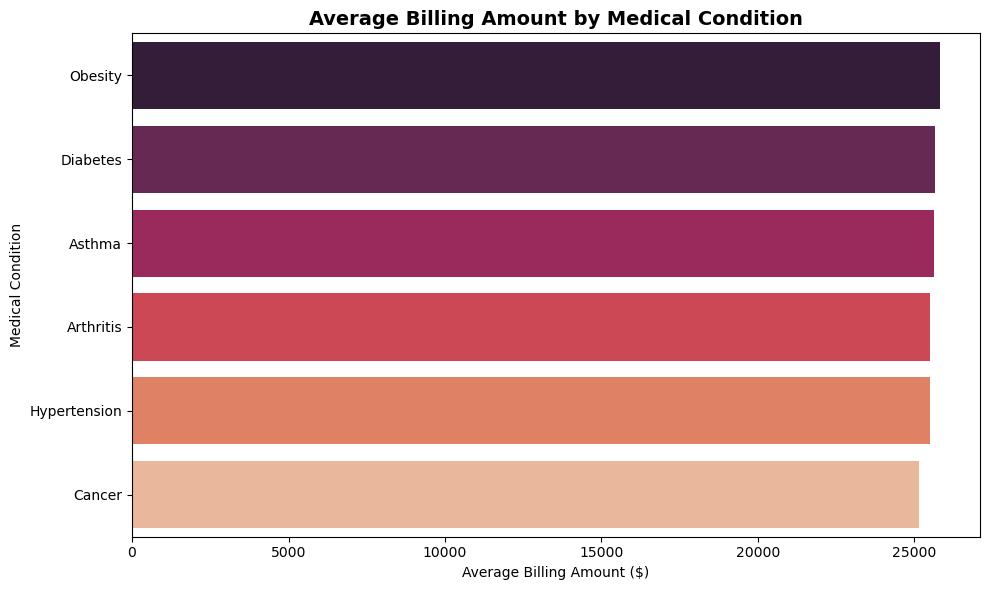

In [17]:

# VISUAL 2: Average Billing by Medical Condition ─

plt.figure(figsize=(10, 6))
avg_billing = df.groupby('Medical Condition')['Billing Amount'].mean().sort_values(ascending=False)
sns.barplot(x=avg_billing.values, y=avg_billing.index, palette="rocket")
plt.title('Average Billing Amount by Medical Condition', fontsize=14, fontweight='bold')
plt.xlabel('Average Billing Amount ($)')
plt.ylabel('Medical Condition')
plt.tight_layout()
plt.savefig('chart2_avg_billing.png', dpi=150)
plt.show()

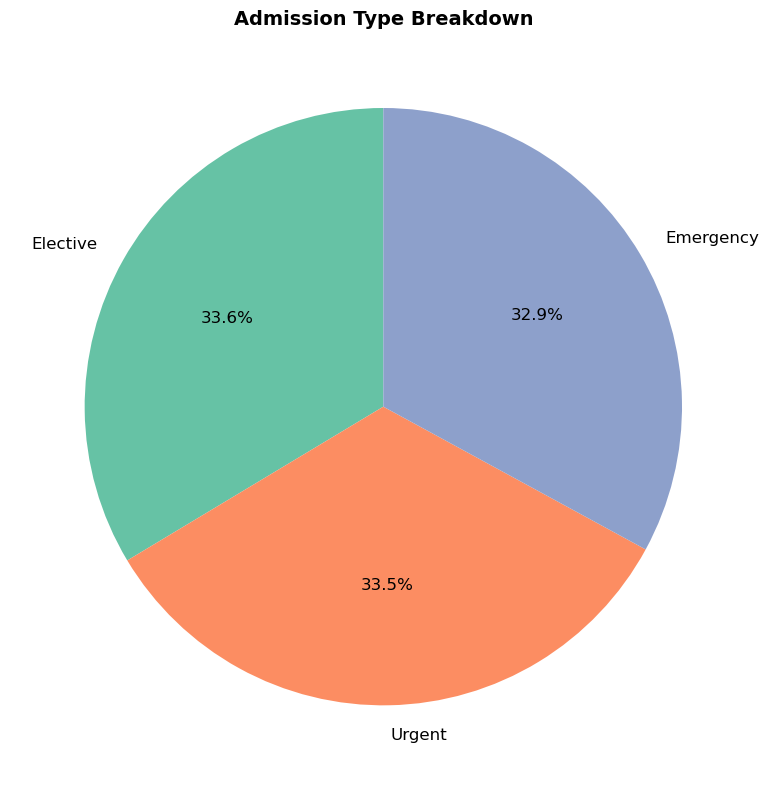

In [18]:
#  VISUAL 4: Admission Type Breakdown (Pie Chart) ─


plt.figure(figsize=(8, 8))
admission_counts = df['Admission Type'].value_counts()
colors = sns.color_palette("Set2")
plt.pie(admission_counts.values, labels=admission_counts.index, autopct='%1.1f%%',
        colors=colors, startangle=90, textprops={'fontsize': 12})
plt.title('Admission Type Breakdown', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('chart4_admission_type.png', dpi=150)
plt.show()

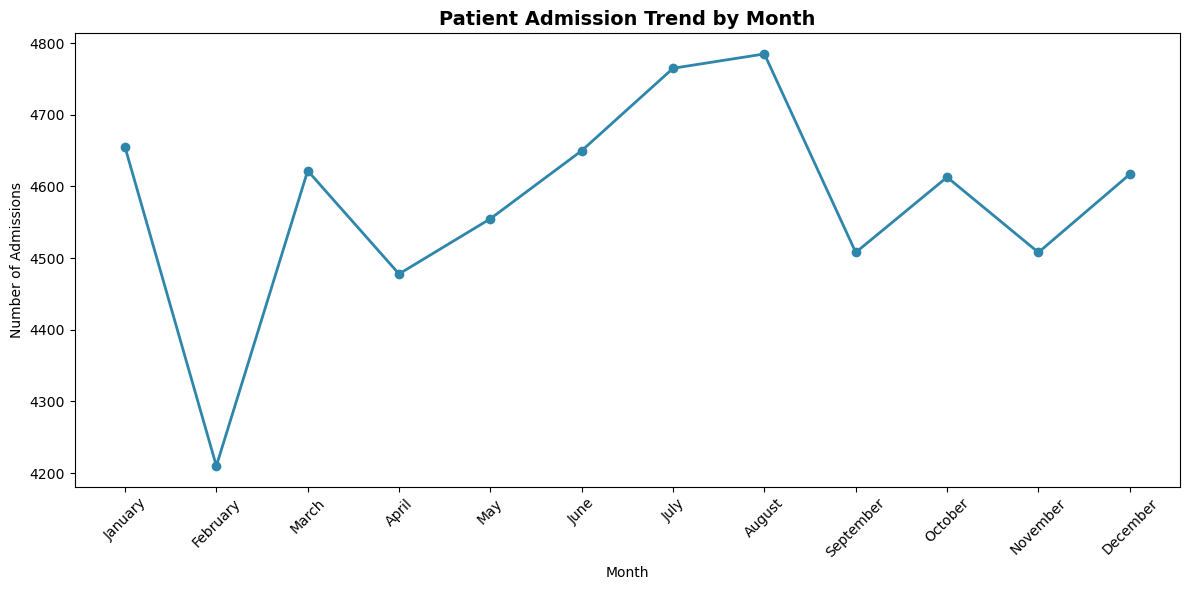

In [19]:

# VISUAL 5: Monthly Admission Trend (Line Chart) ─

plt.figure(figsize=(12, 6))
monthly_trend = df.groupby('Admission Month').size()
 
# Months ko sahi order mein lagana
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']
monthly_trend = monthly_trend.reindex(month_order)
 
plt.plot(monthly_trend.index, monthly_trend.values, marker='o', linewidth=2, color='#2E86AB')
plt.title('Patient Admission Trend by Month', fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Number of Admissions')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('chart5_monthly_trend.png', dpi=150)
plt.show()
 

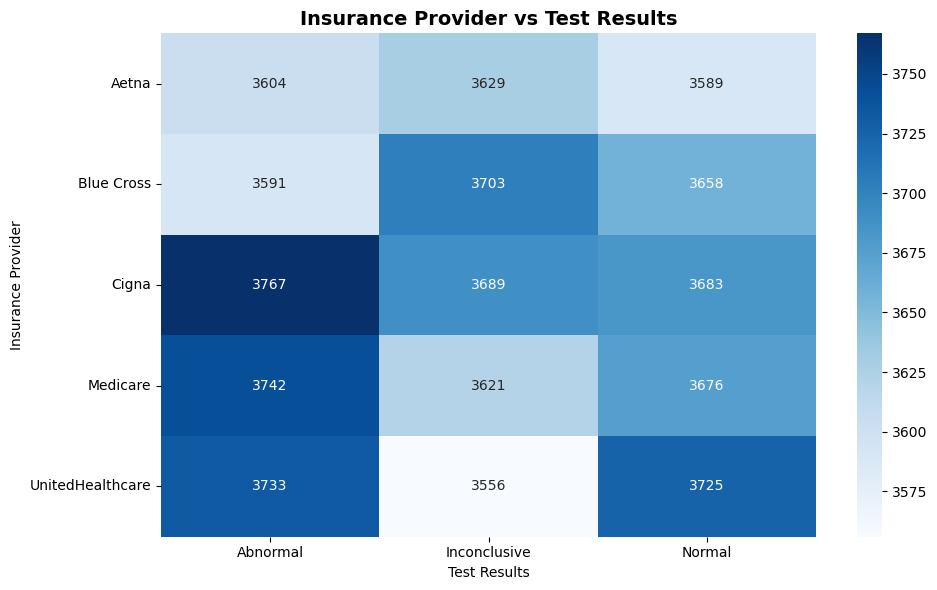

In [20]:

 
# BONUS: Insurance Provider vs Test Results ───────

plt.figure(figsize=(10, 6))
cross_tab = pd.crosstab(df['Insurance Provider'], df['Test Results'])
sns.heatmap(cross_tab, annot=True, fmt='d', cmap='Blues')
plt.title('Insurance Provider vs Test Results', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('chart6_insurance_heatmap.png', dpi=150)
plt.show()
 

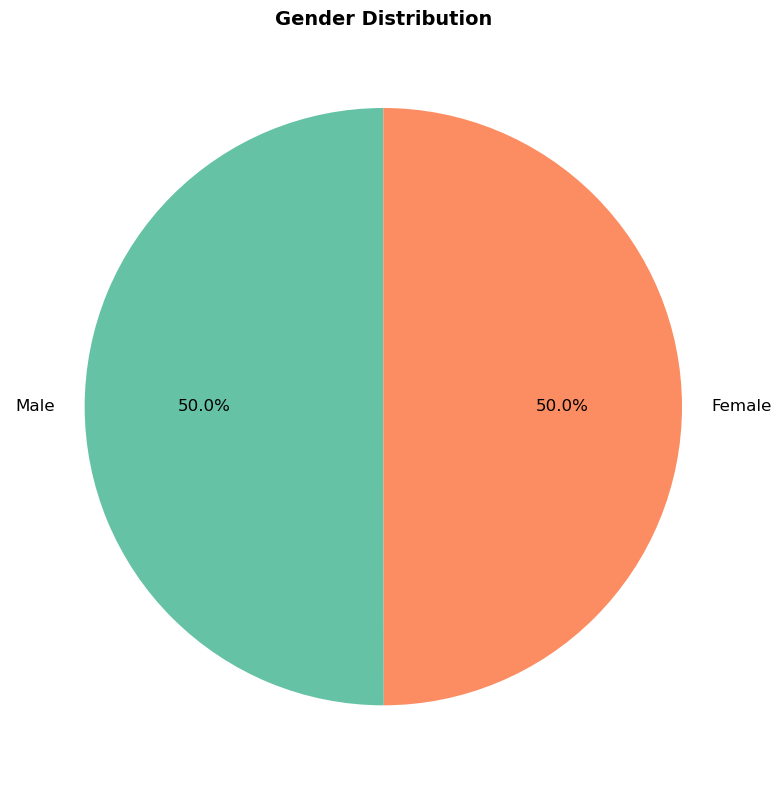

In [21]:
# Gender Distribution ───────

plt.figure(figsize=(8, 8))
gender_counts = df['Gender'].value_counts()
colors = sns.color_palette("Set2")
plt.pie(gender_counts.values, labels=gender_counts.index, autopct='%1.1f%%',
        colors=colors, startangle=90, textprops={'fontsize': 12})
plt.title('Gender Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('chart4_gender_distribution.png', dpi=150)
plt.show()
 